# NTD System Performance — VIA vs. CapMetro (2019–2024)

Compares VIA Metropolitan Transit (San Antonio) and Capital Metro (Austin) across four performance dimensions using NTD Time Series data: farebox recovery ratio, cost per unlinked trip, riders per revenue mile, and ridership recovery relative to pre-COVID 2019 baseline.

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

## 2. Load & Reshape NTD Data

Reads four sheets from the NTD TS2.2 time series workbook, filters to the two target agencies, melts year columns into long format, then pivots metrics into columns — one row per agency per year.

In [2]:
file_path = '2024 TS2.2 Service Data and Operating Expenses Time Series by System.xlsx'
sheets_meta = {
    'OpExp Total': 'Total Operating Expenses',
    'Fares': 'Fares',
    'VRM': 'Vehicle Revenue Miles',
    'UPT': 'Unlinked Passenger Trips'
}
agencies = ['VIA Metropolitan Transit', 'Capital Metropolitan Transportation Authority (CMTA)']
columns_to_keep = ['Agency Name', 'Metric', '2019', '2020', '2021', '2022', '2023', '2024']

frames = []
with pd.ExcelFile(file_path) as xls:
    for sheet, metric_name in sheets_meta.items():
        temp_df = pd.read_excel(xls, sheet)
        temp_df = temp_df[temp_df['Agency Name'].isin(agencies)].copy()
        temp_df['Metric'] = metric_name
        frames.append(temp_df[columns_to_keep])

df = pd.concat(frames, ignore_index=True)

# Melt year columns into long format, then pivot metrics into columns
df_long = df.melt(id_vars=['Agency Name', 'Metric'], var_name='Year', value_name='Amount')
df_clean = df_long.pivot(
    index=['Agency Name', 'Year'],
    columns='Metric',
    values='Amount'
).reset_index()
df_clean.columns.name = None

df_clean

,Agency Name,Year,Fares,Total Operating Expenses,Unlinked Passenger Trips,Vehicle Revenue Miles
0,Capital Metropolitan Transportation Authority ...,2019,22871982.0,234119568.0,31078420.0,27715980.0
1,Capital Metropolitan Transportation Authority ...,2020,15298332.0,229551099.0,22702466.0,24114786.0
2,Capital Metropolitan Transportation Authority ...,2021,12974210.0,236624615.0,16815879.0,22814483.0
3,Capital Metropolitan Transportation Authority ...,2022,15659599.0,283569974.0,20417077.0,22719574.0
4,Capital Metropolitan Transportation Authority ...,2023,17984457.0,345080816.0,24332441.0,23980019.0
5,Capital Metropolitan Transportation Authority ...,2024,15878222.0,390413808.0,26473441.0,25344905.0
6,VIA Metropolitan Transit,2019,22984946.0,222217513.0,42510772.0,38685650.0
7,VIA Metropolitan Transit,2020,15033510.0,222032078.0,32143290.0,33964802.0
8,VIA Metropolitan Transit,2021,12792731.0,223924016.0,23986213.0,31931047.0
9,VIA Metropolitan Transit,2022,14475052.0,224052242.0,25106918.0,31591821.0


## 3. Derived Performance Metrics

- **Farebox Recovery Ratio** — share of operating costs recovered through fares (financial self-sufficiency)
- **Cost per Rider** — operating cost per unlinked trip (efficiency)
- **Riders per Revenue Mile** — ridership relative to service supplied (demand vs. supply)
- **Recovery Arc** — ridership indexed to 2019 = 100 (COVID recovery trajectory)

In [3]:
df_clean['Fare Ratio'] = df_clean['Fares'] / df_clean['Total Operating Expenses']
df_clean['Cost per Rider'] = df_clean['Total Operating Expenses'] / df_clean['Unlinked Passenger Trips']
df_clean['Riders per Revenue Mile'] = df_clean['Unlinked Passenger Trips'] / df_clean['Vehicle Revenue Miles']

# Ridership recovery indexed to 2019 baseline
upt_2019 = df_clean[df_clean['Year'] == '2019'].set_index('Agency Name')['Unlinked Passenger Trips']
df_clean['Recovery Arc'] = (df_clean['Unlinked Passenger Trips'] / df_clean['Agency Name'].map(upt_2019)) * 100

df_clean

,Agency Name,Year,Fares,Total Operating Expenses,Unlinked Passenger Trips,Vehicle Revenue Miles,Fare Ratio,Cost per Rider,Riders per Revenue Mile,Recovery Arc
0,Capital Metropolitan Transportation Authority ...,2019,22871982.0,234119568.0,31078420.0,27715980.0,0.097694,7.533188,1.121318,100.000000
1,Capital Metropolitan Transportation Authority ...,2020,15298332.0,229551099.0,22702466.0,24114786.0,0.066645,10.111285,0.941433,73.048971
2,Capital Metropolitan Transportation Authority ...,2021,12974210.0,236624615.0,16815879.0,22814483.0,0.054830,14.071498,0.737070,54.107895
3,Capital Metropolitan Transportation Authority ...,2022,15659599.0,283569974.0,20417077.0,22719574.0,0.055223,13.888862,0.898656,65.695351
4,Capital Metropolitan Transportation Authority ...,2023,17984457.0,345080816.0,24332441.0,23980019.0,0.052117,14.181923,1.014696,78.293687
5,Capital Metropolitan Transportation Authority ...,2024,15878222.0,390413808.0,26473441.0,25344905.0,0.040670,14.747377,1.044527,85.182712
6,VIA Metropolitan Transit,2019,22984946.0,222217513.0,42510772.0,38685650.0,0.103434,5.227322,1.098877,100.000000
7,VIA Metropolitan Transit,2020,15033510.0,222032078.0,32143290.0,33964802.0,0.067709,6.907572,0.946371,75.612106
8,VIA Metropolitan Transit,2021,12792731.0,223924016.0,23986213.0,31931047.0,0.057130,9.335530,0.751188,56.423847
9,VIA Metropolitan Transit,2022,14475052.0,224052242.0,25106918.0,31591821.0,0.064606,8.923925,0.794728,59.060132


## 4. Visualization

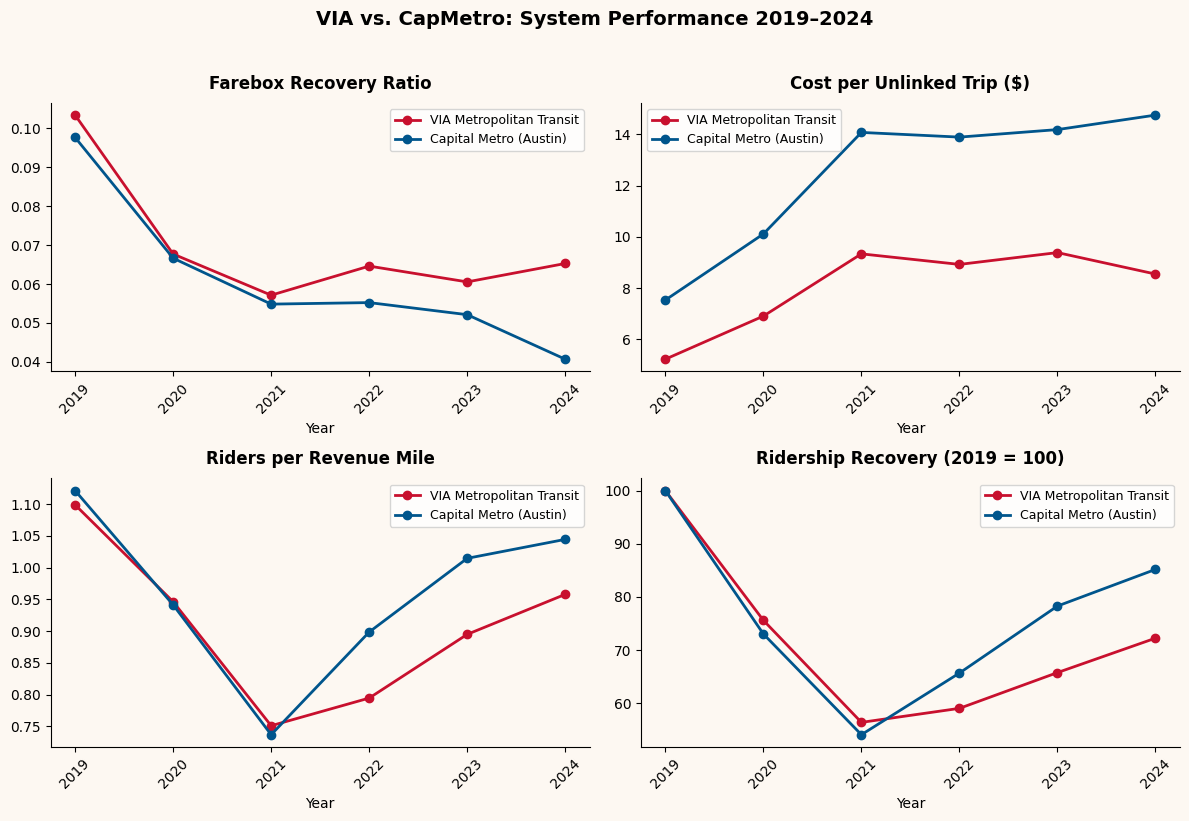

In [5]:
# CivicData SA brand palette
VIA_COLOR = '#C8102E'
CAP_COLOR = '#00558C'
BACKGROUND = '#fdf8f2'

agencies = ['VIA Metropolitan Transit', 'Capital Metropolitan Transportation Authority (CMTA)']
labels = ['VIA Metropolitan Transit', 'Capital Metro (Austin)']
colors = [VIA_COLOR, CAP_COLOR]

metrics = [
    ('Fare Ratio',             'Farebox Recovery Ratio',          '{:.1%}'),
    ('Cost per Rider',         'Cost per Unlinked Trip ($)',       '${:.2f}'),
    ('Riders per Revenue Mile','Riders per Revenue Mile',          '{:.2f}'),
    ('Recovery Arc',           'Ridership Recovery (2019 = 100)', '{:.0f}'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), facecolor=BACKGROUND)
axes = axes.flatten()

for ax, (col, title, fmt) in zip(axes, metrics):
    ax.set_facecolor(BACKGROUND)
    for agency, label, color in zip(agencies, labels, colors):
        subset = df_clean[df_clean['Agency Name'] == agency].sort_values('Year')
        ax.plot(subset['Year'], subset[col], marker='o', label=label, color=color, linewidth=2)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Year')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks(df_clean['Year'].unique())
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('VIA vs. CapMetro: System Performance 2019–2024', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ntd_comparison.png', dpi=150, bbox_inches='tight', facecolor=BACKGROUND)
plt.show()